# AI Waste Sorter

### Project Overview
In this project we try to build an AI model that can classify the kind of waste into 12 classes from images.

# Handling Class Imbalance

This Notebook will handle class imbalance which found in the dataset with ratio 8.77 using Data Augmentation for minor category, Class Weights Calculation for training, and Balanced Dataset Generation

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import json
import shutil
from collections import Counter
import cv2

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load Previous Analysis Results

In [24]:
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / 'processed_data'
TRAIN_DIR = PROCESSED_DIR / 'train'
BALANCED_TRAIN_DIR = PROCESSED_DIR / 'train_balanced'
BALANCED_TRAIN_DIR.mkdir(exist_ok=True)

with open(PROCESSED_DIR / 'dataset_summary_report.json', 'r') as f:
    summary = json.load(f)

train_df = pd.read_csv(PROCESSED_DIR / 'train_split.csv')

print("Current train distribution:")
train_counts = train_df['category'].value_counts().sort_index()
print(train_counts)
print(f"\nTotal train images: {len(train_df)}")
print(f"Class imbalance ratio: {train_counts.max() / train_counts.min():.2f}")

Current train distribution:
category
battery         756
biological      788
brown-glass     485
cardboard       712
clothes        4260
green-glass     503
metal           615
paper           840
plastic         692
shoes          1581
trash           557
white-glass     620
Name: count, dtype: int64

Total train images: 12409
Class imbalance ratio: 8.78


## 2. Define Balancing Strategy

In [25]:
train_distribution = summary['data_split']['train']['distribution']
categories = list(train_distribution.keys())
counts = list(train_distribution.values())

max_count = max(counts)
min_count = min(counts)
median_count = int(np.median(counts))
mean_count = int(np.mean(counts))

print(f"Max samples: {max_count} (clothes)")
print(f"Min samples: {min_count} (brown-glass)")
print(f"Median samples: {median_count}")
print(f"Mean samples: {mean_count}")
print(f"\nImbalance ratio: {max_count/min_count:.2f}")

TARGET_SAMPLES_PER_CLASS = median_count

print(f"\nBalancing strategy: Target {TARGET_SAMPLES_PER_CLASS} samples per class")
print("This uses median to balance between under/over-represented classes")

Max samples: 4260 (clothes)
Min samples: 485 (brown-glass)
Median samples: 702
Mean samples: 1034

Imbalance ratio: 8.78

Balancing strategy: Target 702 samples per class
This uses median to balance between under/over-represented classes


## 3. Calculate Augmentation Needs

In [26]:
augmentation_plan = {}

for category, count in train_distribution.items():
    if count < TARGET_SAMPLES_PER_CLASS:
        needed = TARGET_SAMPLES_PER_CLASS - count
        augmentation_plan[category] = {
            'current': count,
            'target': TARGET_SAMPLES_PER_CLASS,
            'augment_needed': needed,
            'augment_ratio': needed / count
        }
    else:
        augmentation_plan[category] = {
            'current': count,
            'target': TARGET_SAMPLES_PER_CLASS,
            'augment_needed': 0,
            'augment_ratio': 0,
            'action': 'undersample' if count > TARGET_SAMPLES_PER_CLASS else 'keep_all'
        }

print("Augmentation plan per category:")
for cat, plan in augmentation_plan.items():
    if plan['augment_needed'] > 0:
        print(f"{cat:15} - Current: {plan['current']:4}, Need: {plan['augment_needed']:4} more ({plan['augment_ratio']:.2f}x)")
    else:
        action = plan.get('action', 'keep_all')
        if action == 'undersample':
            print(f"{cat:15} - Current: {plan['current']:4}, Will undersample to {plan['target']}")
        else:
            print(f"{cat:15} - Current: {plan['current']:4}, Keep all (already balanced)")

Augmentation plan per category:
battery         - Current:  756, Will undersample to 702
biological      - Current:  788, Will undersample to 702
brown-glass     - Current:  485, Need:  217 more (0.45x)
cardboard       - Current:  712, Will undersample to 702
clothes         - Current: 4260, Will undersample to 702
green-glass     - Current:  503, Need:  199 more (0.40x)
metal           - Current:  615, Need:   87 more (0.14x)
paper           - Current:  840, Will undersample to 702
plastic         - Current:  692, Need:   10 more (0.01x)
shoes           - Current: 1581, Will undersample to 702
trash           - Current:  557, Need:  145 more (0.26x)
white-glass     - Current:  620, Need:   82 more (0.13x)


## 4. Setup Augmentation

In [27]:
augmentor_aggressive = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.25,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

augmentor_moderate = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

augmentor_light = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

print("Augmentation levels configuration:")
print("- Aggressive: For classes needing >1.5x augmentation")
print("- Moderate: For classes needing 1.0-1.5x augmentation")
print("- Light: For classes needing <1.0x augmentation")

Augmentation levels configuration:
- Aggressive: For classes needing >1.5x augmentation
- Moderate: For classes needing 1.0-1.5x augmentation
- Light: For classes needing <1.0x augmentation


## 5. Augmentation Function

In [28]:
def augment_images(source_dir, output_dir, category, num_augmentations, augmentor):
    """
    Generate augmented images for a given category
    """
    category_source = source_dir / category
    category_output = output_dir / category
    category_output.mkdir(exist_ok=True, parents=True)
    
    original_images = list(category_source.glob('*'))
    original_images = [f for f in original_images if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
    
    for img_path in original_images:
        shutil.copy2(img_path, category_output / img_path.name)
    
    if num_augmentations == 0:
        return len(original_images)
    
    augmentations_per_image = int(np.ceil(num_augmentations / len(original_images)))
    
    total_generated = 0
    for img_path in tqdm(original_images, desc=f"Augmenting {category}"):
        try:
            img = load_img(img_path)
            img_array = img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            
            base_name = img_path.stem
            ext = img_path.suffix
            
            aug_iter = augmentor.flow(
                img_array,
                batch_size=1,
                save_to_dir=category_output,
                save_prefix=f'aug_{base_name}',
                save_format='jpg'
            )
            
            for i in range(min(augmentations_per_image, num_augmentations - total_generated)):
                next(aug_iter)
                total_generated += 1
                
                if total_generated >= num_augmentations:
                    break
            
            if total_generated >= num_augmentations:
                break
                
        except Exception as e:
            print(f"Error augmenting {img_path}: {e}")
    
    return len(original_images) + total_generated

## 6. Execute Balancing

In [29]:
balanced_distribution = {}

for category, plan in augmentation_plan.items():
    print(f"\nProcessing category: {category}")
    
    if plan['augment_needed'] > 0:
        ratio = plan['augment_ratio']
        
        if ratio > 1.5:
            augmentor = augmentor_aggressive
            level = "aggressive"
        elif ratio > 1.0:
            augmentor = augmentor_moderate
            level = "moderate"
        else:
            augmentor = augmentor_light
            level = "light"
        
        print(f"Augmentation level: {level} ({ratio:.2f}x)")
        
        final_count = augment_images(
            TRAIN_DIR,
            BALANCED_TRAIN_DIR,
            category,
            plan['augment_needed'],
            augmentor
        )
    else:
        category_source = TRAIN_DIR / category
        category_output = BALANCED_TRAIN_DIR / category
        category_output.mkdir(exist_ok=True, parents=True)
        
        original_images = list(category_source.glob('*'))
        original_images = [f for f in original_images if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
        
        action = plan.get('action', 'keep_all')
        
        if action == 'undersample':
            print(f"Undersampling from {len(original_images)} to {plan['target']}")
            np.random.seed(42)
            selected_images = np.random.choice(original_images, plan['target'], replace=False)
            
            for img_path in tqdm(selected_images, desc=f"Copying {category}"):
                shutil.copy2(img_path, category_output / img_path.name)
            
            final_count = len(selected_images)
        else:
            print(f"Keeping all {len(original_images)} images")
            for img_path in tqdm(original_images, desc=f"Copying {category}"):
                shutil.copy2(img_path, category_output / img_path.name)
            
            final_count = len(original_images)
    
    balanced_distribution[category] = final_count
    print(f"Final count for {category}: {final_count}")


Processing category: battery
Undersampling from 756 to 702


Copying battery: 100%|██████████| 702/702 [00:15<00:00, 45.58it/s]


Final count for battery: 702

Processing category: biological
Undersampling from 788 to 702


Copying biological: 100%|██████████| 702/702 [00:13<00:00, 52.01it/s]


Final count for biological: 702

Processing category: brown-glass
Augmentation level: light (0.45x)


...

Final count for shoes: 702

Processing category: trash
Augmentation level: light (0.26x)


Augmenting trash:  26%|██▌       | 144/557 [00:02<00:08, 48.06it/s]


Final count for trash: 702

Processing category: white-glass
Augmentation level: light (0.13x)


Augmenting white-glass:  13%|█▎        | 81/620 [00:02<00:19, 27.00it/s]

Final count for white-glass: 702


## 7. Verify Balanced Distribution

In [30]:
balanced_counts = pd.Series(balanced_distribution).sort_index()

print("Balanced distribution:")
print(balanced_counts)
print(f"\nTotal balanced train images: {balanced_counts.sum()}")
print(f"New class imbalance ratio: {balanced_counts.max() / balanced_counts.min():.2f}")
print(f"Mean samples per class: {balanced_counts.mean():.1f}")
print(f"Std samples per class: {balanced_counts.std():.1f}")

Balanced distribution:
battery        702
biological     702
brown-glass    702
cardboard      702
clothes        702
green-glass    702
metal          702
paper          702
plastic        702
shoes          702
trash          702
white-glass    702
dtype: int64

Total balanced train images: 8424
New class imbalance ratio: 1.00
Mean samples per class: 702.0
Std samples per class: 0.0


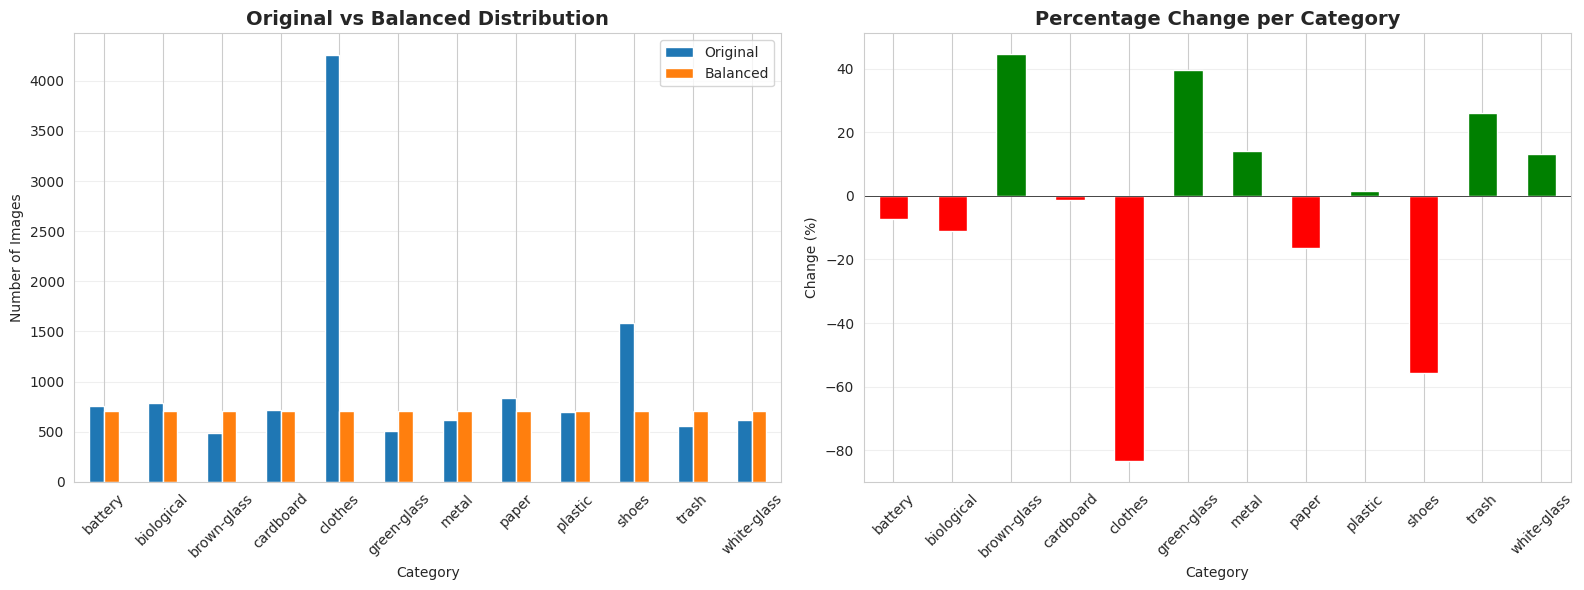

In [31]:
comparison_df = pd.DataFrame({
    'Original': train_counts,
    'Balanced': balanced_counts
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

comparison_df.plot(kind='bar', ax=axes[0])
axes[0].set_title('Original vs Balanced Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['Original', 'Balanced'])
axes[0].grid(axis='y', alpha=0.3)

increase_pct = ((balanced_counts - train_counts) / train_counts * 100).fillna(0)
colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in increase_pct]
increase_pct.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Percentage Change per Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Change (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'class_balance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Calculate Class Weights

In [32]:
total_samples = balanced_counts.sum()
num_classes = len(balanced_counts)

class_weights_dict = {}
for idx, (category, count) in enumerate(balanced_counts.items()):
    weight = total_samples / (num_classes * count)
    class_weights_dict[idx] = weight

category_to_index = {cat: idx for idx, cat in enumerate(sorted(categories))}
index_to_category = {idx: cat for cat, idx in category_to_index.items()}

print("Class weights for training:")
for idx, weight in class_weights_dict.items():
    category = index_to_category[idx]
    count = balanced_counts[category]
    print(f"Class {idx} ({category:15}): {weight:.4f} (samples: {count})")

weights_config = {
    'class_weights': class_weights_dict,
    'category_to_index': category_to_index,
    'index_to_category': index_to_category
}

with open(PROCESSED_DIR / 'class_weights.json', 'w') as f:
    json.dump(weights_config, f, indent=2)

Class weights for training:
Class 0 (battery        ): 1.0000 (samples: 702)
Class 1 (biological     ): 1.0000 (samples: 702)
Class 2 (brown-glass    ): 1.0000 (samples: 702)
Class 3 (cardboard      ): 1.0000 (samples: 702)
Class 4 (clothes        ): 1.0000 (samples: 702)
Class 5 (green-glass    ): 1.0000 (samples: 702)
Class 6 (metal          ): 1.0000 (samples: 702)
Class 7 (paper          ): 1.0000 (samples: 702)
Class 8 (plastic        ): 1.0000 (samples: 702)
Class 9 (shoes          ): 1.0000 (samples: 702)
Class 10 (trash          ): 1.0000 (samples: 702)
Class 11 (white-glass    ): 1.0000 (samples: 702)


## 9. Sample Augmentations

Showing augmentation samples for minority classes:

Category: brown-glass


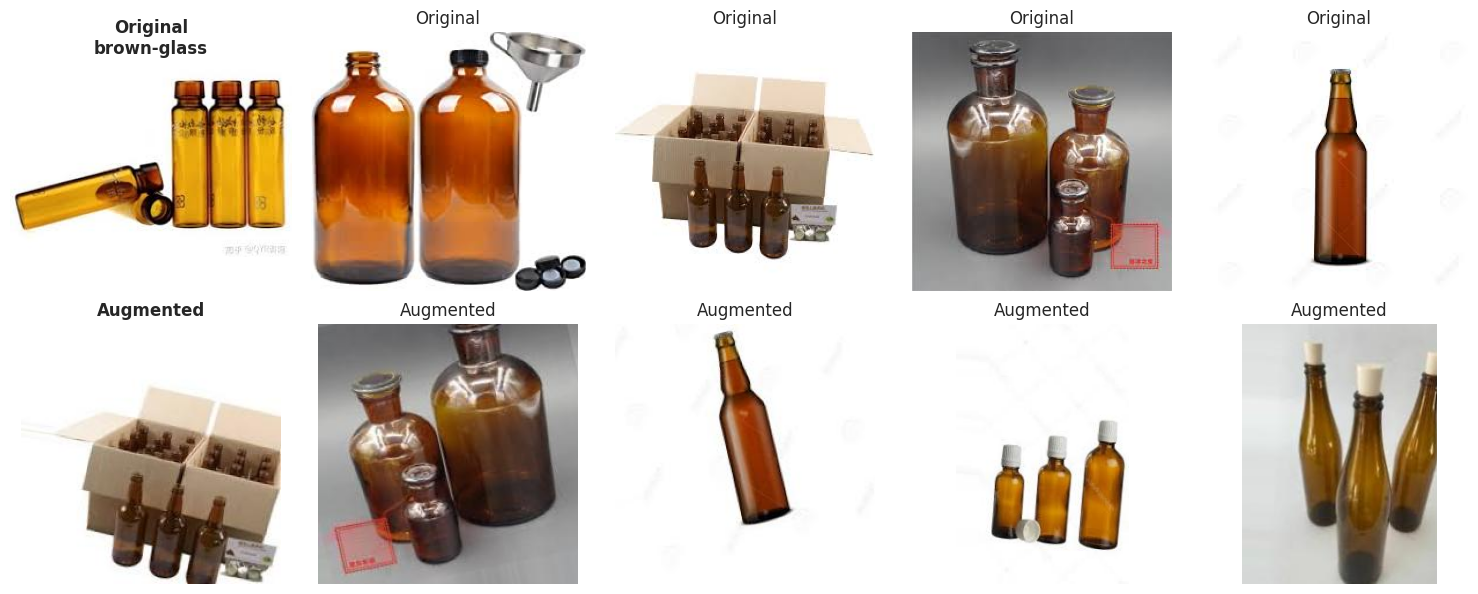


Category: green-glass


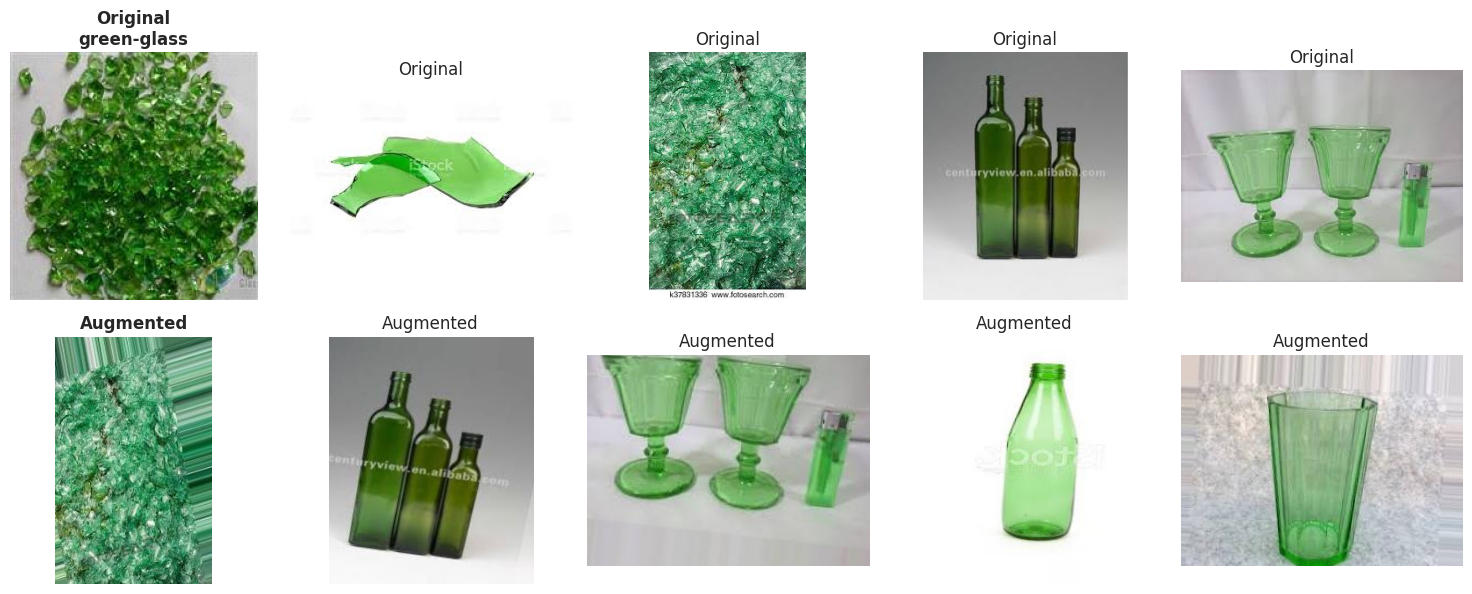


Category: metal


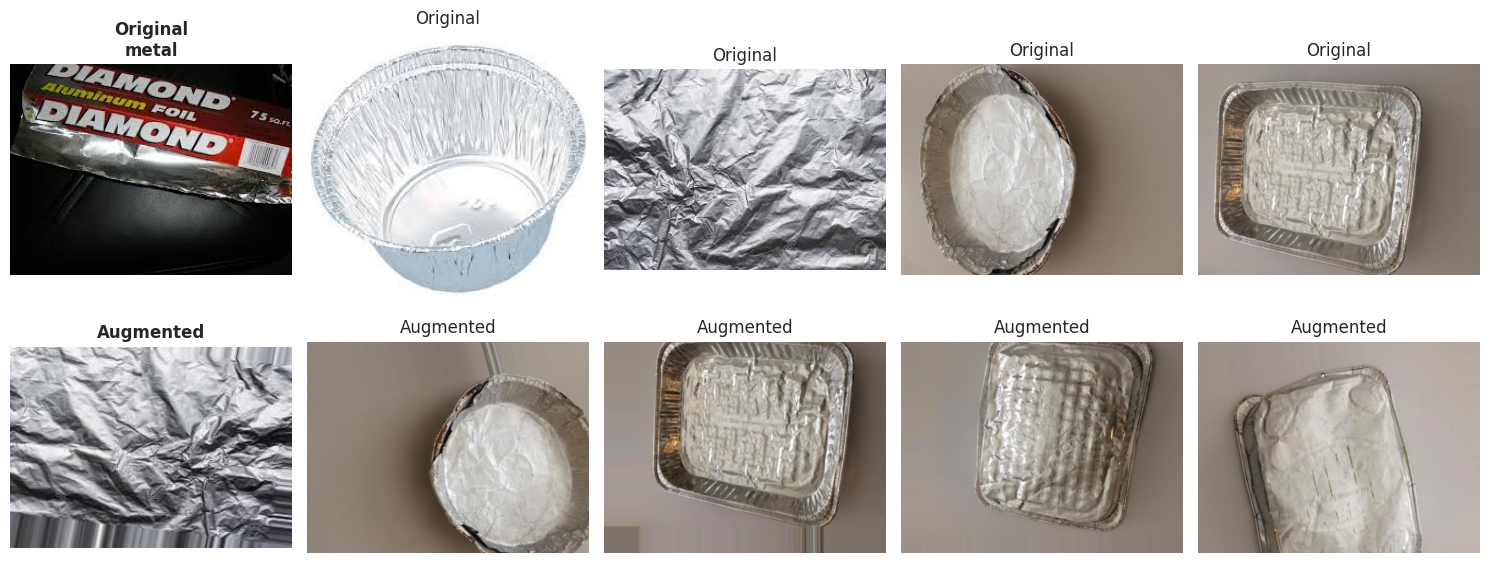

In [33]:
def show_augmentation_samples(category, num_samples=6):
    """
    Show original and augmented images for a given category
    """
    category_dir = BALANCED_TRAIN_DIR / category
    
    original_images = [f for f in category_dir.glob('*') if not f.name.startswith('aug_')]
    augmented_images = [f for f in category_dir.glob('aug_*')]
    
    if len(augmented_images) == 0:
        print(f"No augmented images found for {category}")
        return
    
    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples * 3, 6))
    
    for i in range(min(num_samples, len(original_images))):
        img = Image.open(original_images[i])
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title(f'Original\n{category}', fontweight='bold')
        else:
            axes[0, i].set_title('Original')
    
    for i in range(min(num_samples, len(augmented_images))):
        img = Image.open(augmented_images[i])
        axes[1, i].imshow(img)
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Augmented', fontweight='bold')
        else:
            axes[1, i].set_title('Augmented')
    
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / f'augmentation_samples_{category}.png', dpi=150, bbox_inches='tight')
    plt.show()

minority_classes = [cat for cat, plan in augmentation_plan.items() if plan['augment_needed'] > 0]
if minority_classes:
    print("Showing augmentation samples for minority classes:")
    for category in minority_classes[:3]:
        print(f"\nCategory: {category}")
        show_augmentation_samples(category, num_samples=5)

## 10. Save Balanced Dataset Info

In [34]:
balanced_info = {
    'balancing_strategy': {
        'method': 'augmentation_and_undersampling',
        'target_samples_per_class': TARGET_SAMPLES_PER_CLASS,
        'augmentation_levels': {
            'aggressive': 'ratio > 1.5',
            'moderate': '1.0 < ratio <= 1.5',
            'light': 'ratio <= 1.0'
        }
    },
    'original_distribution': train_distribution,
    'balanced_distribution': balanced_distribution,
    'statistics': {
        'original': {
            'total': int(train_counts.sum()),
            'min': int(train_counts.min()),
            'max': int(train_counts.max()),
            'mean': float(train_counts.mean()),
            'std': float(train_counts.std()),
            'imbalance_ratio': float(train_counts.max() / train_counts.min())
        },
        'balanced': {
            'total': int(balanced_counts.sum()),
            'min': int(balanced_counts.min()),
            'max': int(balanced_counts.max()),
            'mean': float(balanced_counts.mean()),
            'std': float(balanced_counts.std()),
            'imbalance_ratio': float(balanced_counts.max() / balanced_counts.min())
        }
    },
    'augmentation_plan': augmentation_plan,
    'class_weights': class_weights_dict,
    'category_mapping': {
        'category_to_index': category_to_index,
        'index_to_category': index_to_category
    }
}

with open(PROCESSED_DIR / 'balanced_dataset_info.json', 'w') as f:
    json.dump(balanced_info, f, indent=2)

print("\nBalanced Dataset Summary:")
print(json.dumps(balanced_info['statistics'], indent=2))


Balanced Dataset Summary:
{
  "original": {
    "total": 12409,
    "min": 485,
    "max": 4260,
    "mean": 1034.0833333333333,
    "std": 1055.729688055813,
    "imbalance_ratio": 8.783505154639176
  },
  "balanced": {
    "total": 8424,
    "min": 702,
    "max": 702,
    "mean": 702.0,
    "std": 0.0,
    "imbalance_ratio": 1.0
  }
}
